#**I. IMPORT NECCESSARY LIBRARIES**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway


#**II. INITIAL DATA SET UP**

In [ ]:
def extract(data_path: str, test_path: str) -> tuple:
    """
    Extract data from the Adult dataset files.

    Parameters:
    - data_path : str
        Path to the adult.data file.
    - test_path : str
        Path to the adult.test file.

    Returns:
    - tuple of pd.DataFrame
        A tuple containing two DataFrames: one for training data and one for test data.
    """
    # Column names from UCI Adult dataset
    column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]

    # Read training data
    train_df = pd.read_csv(data_path, header=None, names=column_names, skipinitialspace=True)

    # Read test data and clean
    test_df = pd.read_csv(test_path, header=0, names=column_names, skipinitialspace=True, comment='|')
    test_df['income'] = test_df['income'].str.replace('.', '', regex=False)  # Remove trailing period

    return train_df, test_df

def transform(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a 'dataset_type' column and combine the train and test sets.

    Parameters:
    - train_df : pd.DataFrame
        Training data.
    - test_df : pd.DataFrame
        Test data.

    Returns:
    - pd.DataFrame
        Combined DataFrame with a new 'dataset_type' column indicating origin.
    """
    train_df["dataset_type"] = "train"
    test_df["dataset_type"] = "test"
    return pd.concat([train_df, test_df], ignore_index=True)

def load(adult_data: pd.DataFrame, output_path: str) -> None:
    """
    Save the combined adult dataset to a CSV file.

    Parameters:
    - adult_data : pd.DataFrame
        Combined dataset with 'dataset_type' column.
    - output_path : str
        Path where the CSV will be saved.
    """
    adult_data.to_csv(output_path, index=False)

In [ ]:
data_path = '/content/adult.data'
test_path = '/content/adult.test'

# Extract the train and test datasets
train_df, test_df = extract(data_path, test_path)

# Transform by adding dataset_type and combining them
adult_data = transform(train_df, test_df)

# Load/save the final combined dataset to CSV
load(adult_data, "combined_adult_data.csv")
print(adult_data.shape)
adult_data.head()

(48841, 16)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,dataset_type
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


#**III. Exploratory Data Analysis (EDA)**

##**1. Summary of data information**

In [ ]:
# Number of records
print("Number of records:", adult_data.shape[0])

# Number of variables
print("Number of variables:", adult_data.shape[1])

# Data types of each variable
print("\nData types of each variable:")
print(adult_data.dtypes)

Number of records: 48841
Number of variables: 16

Data types of each variable:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dataset_type      object
dtype: object


In [ ]:
# Replace "?" with NaN across the whole DataFrame
adult_data.replace('?', np.nan, inplace=True)

# Check for missing values (including those originally marked as "?")
print("\nMissing values per column:")
print(adult_data.isnull().sum())


Missing values per column:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dataset_type         0
dtype: int64


In [ ]:
# Check for duplicate rows
print("\nNumber of duplicate rows:", adult_data.duplicated().sum())
adult_data = adult_data.drop_duplicates()
print("\nNumber of duplicate rows after remove:", adult_data.duplicated().sum())


Number of duplicate rows: 29

Number of duplicate rows after remove: 0


##**2. Statistical analysis descriptions**

###**2.1 Calculate statistics**

In [ ]:
#only describe numeric columns
adult_data.describe().T


,count,mean,std,min,25%,50%,75%,max
age,48812.0,38.647628,13.709006,17.0,28.0,37.0,48.0,90.0
fnlwgt,48812.0,189667.144206,105607.191386,12285.0,117553.5,178138.5,237621.0,1490400.0
education-num,48812.0,10.078751,2.570245,1.0,9.0,10.0,12.0,16.0
capital-gain,48812.0,1079.730824,7454.260737,0.0,0.0,0.0,0.0,99999.0
capital-loss,48812.0,87.556093,403.122539,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48812.0,40.425059,12.391081,1.0,40.0,40.0,45.0,99.0


In [ ]:
#describe category columns
adult_data.describe(include="object").T

,count,unique,top,freq
workclass,46013,8,Private,33878
education,48812,16,HS-grad,15777
marital-status,48812,7,Married-civ-spouse,22372
occupation,46003,14,Prof-specialty,6167
relationship,48812,6,Husband,19709
race,48812,5,White,41736
sex,48812,2,Male,32630
native-country,47956,41,United-States,43809
income,48812,2,<=50K,37127
dataset_type,48812,2,train,32537


###**2.2 Visualize charts to identify data trends**

In [ ]:
def plot_histogram(dataframe: pd.DataFrame, column: str, bins: int = 30):
    """
    Plot a histogram for a specified numerical column in the DataFrame using seaborn.

    Parameters:
    - dataframe (pd.DataFrame): The DataFrame containing the data.
    - column (str): The numerical column to visualize.
    - bins (int): Number of histogram bins. Default is 30.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(dataframe[column], bins=bins, kde=True, color='blue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

def plot_bar_chart(dataframe: pd.DataFrame, column: str):
    """
    Plot a bar chart for a specified categorical column using seaborn.

    Parameters:
    - dataframe (pd.DataFrame): The DataFrame containing the data.
    - column (str): The categorical column to visualize.
    """
    plt.figure(figsize=(10, 6))

    if column == 'capital-gain vs capital-loss':
        mean_values = dataframe[['capital-gain', 'capital-loss']].mean()
        plt.bar(mean_values.index, mean_values.values, color=['skyblue', 'salmon'])
        plt.title('Mean Capital Gain vs Capital Loss')
        plt.ylabel('Mean Amount')
        plt.grid(axis='y')
    else:
        sns.countplot(x=dataframe[column], palette='coolwarm')
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.xticks(rotation=45)
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

def plot_pie_chart(dataframe: pd.DataFrame, column: str):
    """
    Plot a pie chart for specified column with special handling for 'native-country'

    Parameters:
    - dataframe (pd.DataFrame): DataFrame containing the data
    - column (str): Column to visualize (special handling for 'native-country')
    """
    plt.figure(figsize=(8, 8))

    if column == 'native-country':
        # Special grouping for country data
        group_counts = dataframe[column].apply(
            lambda x: 'United States' if x in ('United-States', 'United States') else 'Other'
        ).value_counts().reindex(['United States', 'Other'])
        title = 'Records: United States vs. Other Countries'
    else:
        # Regular value counts for other columns
        group_counts = dataframe[column].value_counts()
        title = f'Distribution of {column}'

    plt.pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%')
    plt.title(title)
    plt.axis('equal')
    plt.show()

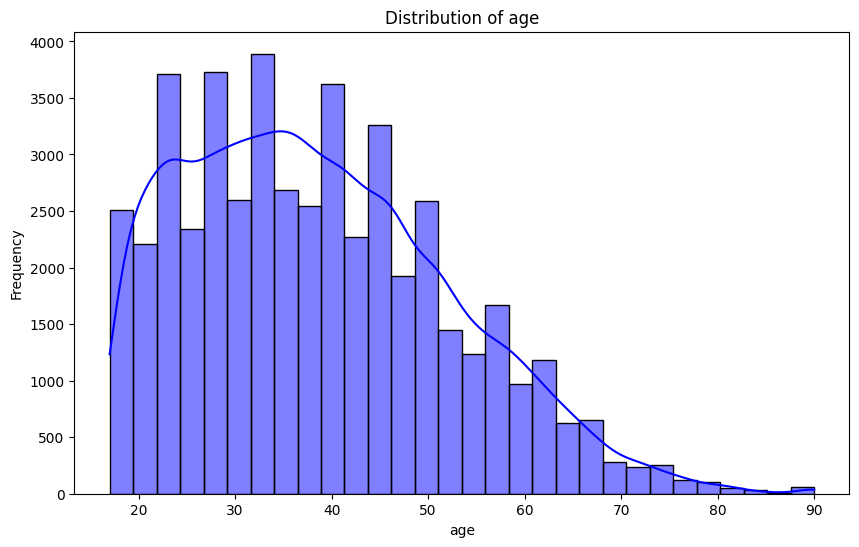

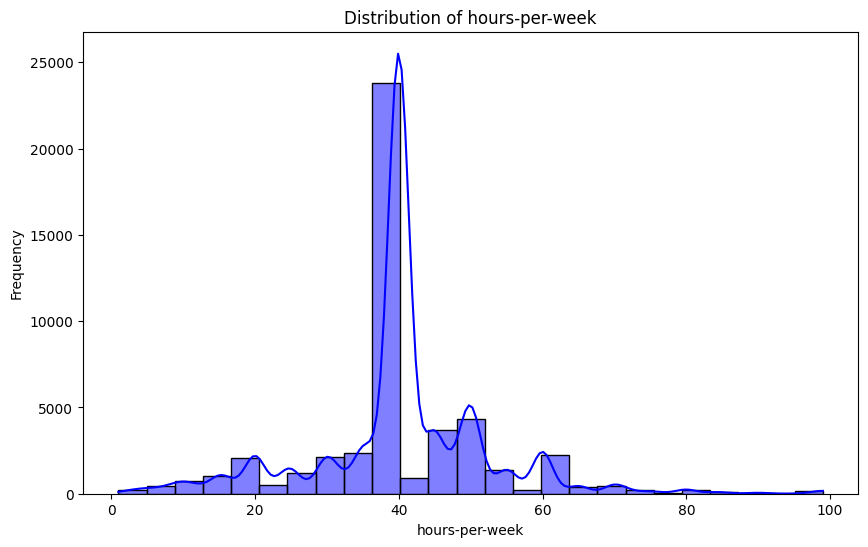

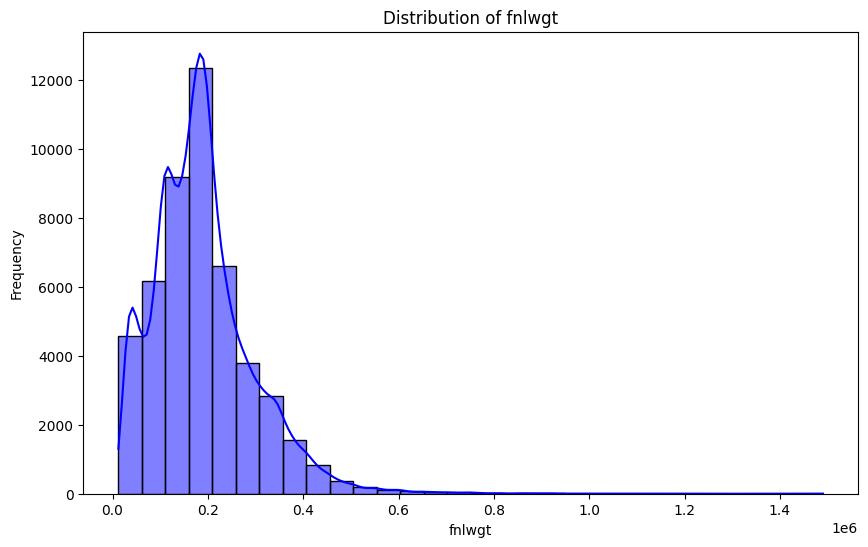

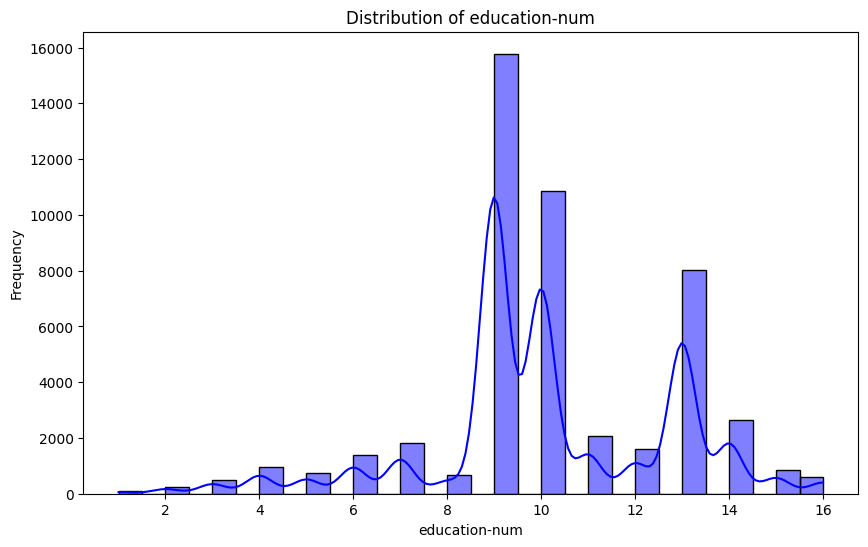

In [ ]:
plot_histogram(adult_data, 'age', bins=30)
plot_histogram(adult_data, 'hours-per-week', bins=25)
plot_histogram(adult_data, 'fnlwgt', bins=30)
plot_histogram(adult_data, 'education-num', bins=30)

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


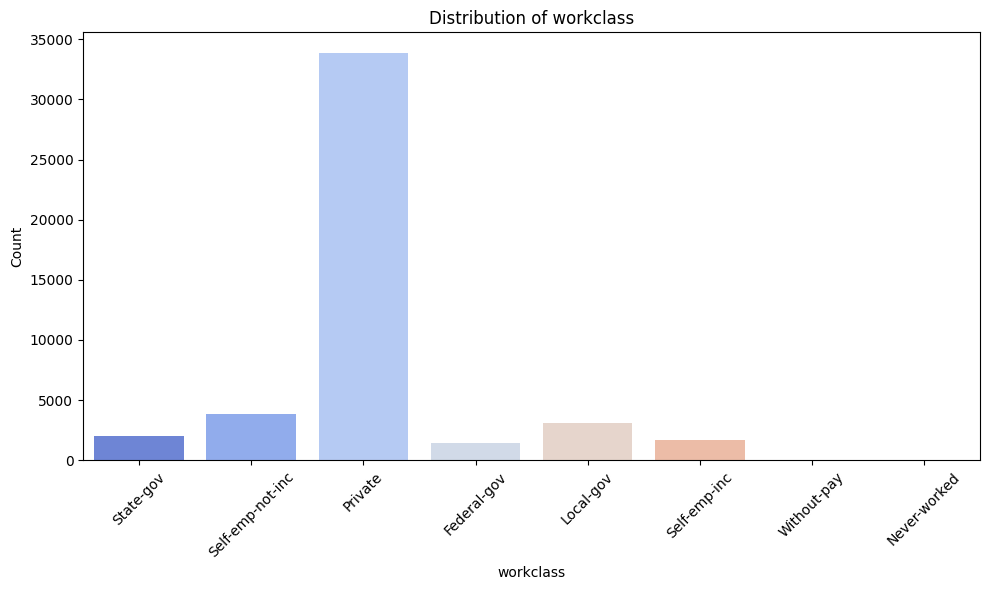

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


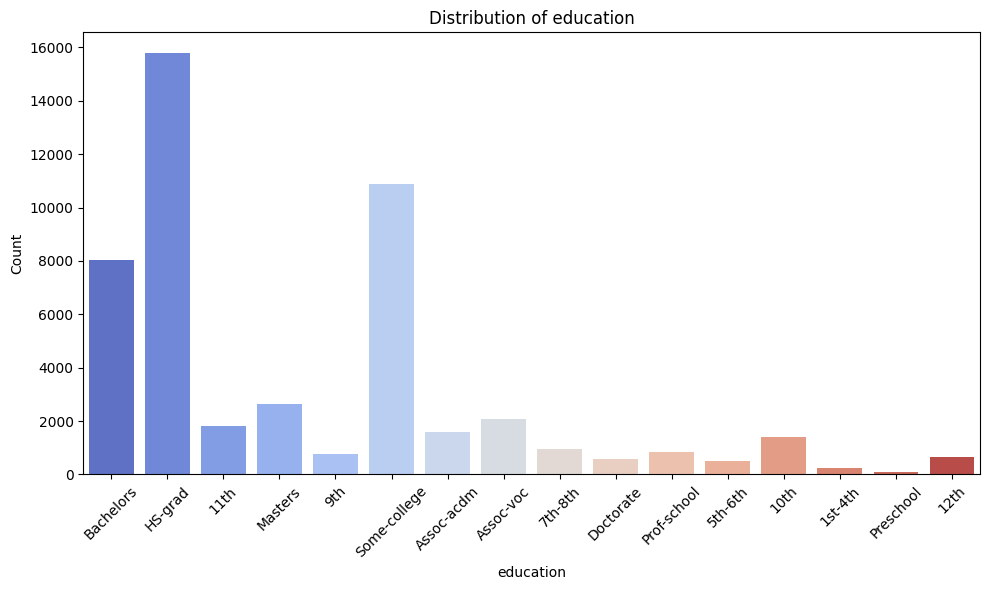

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


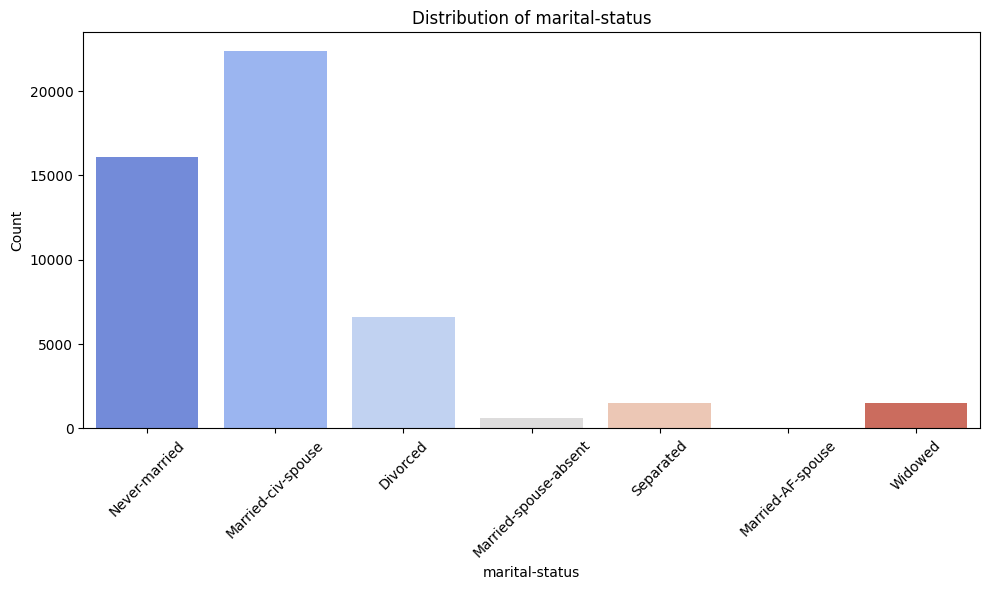

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


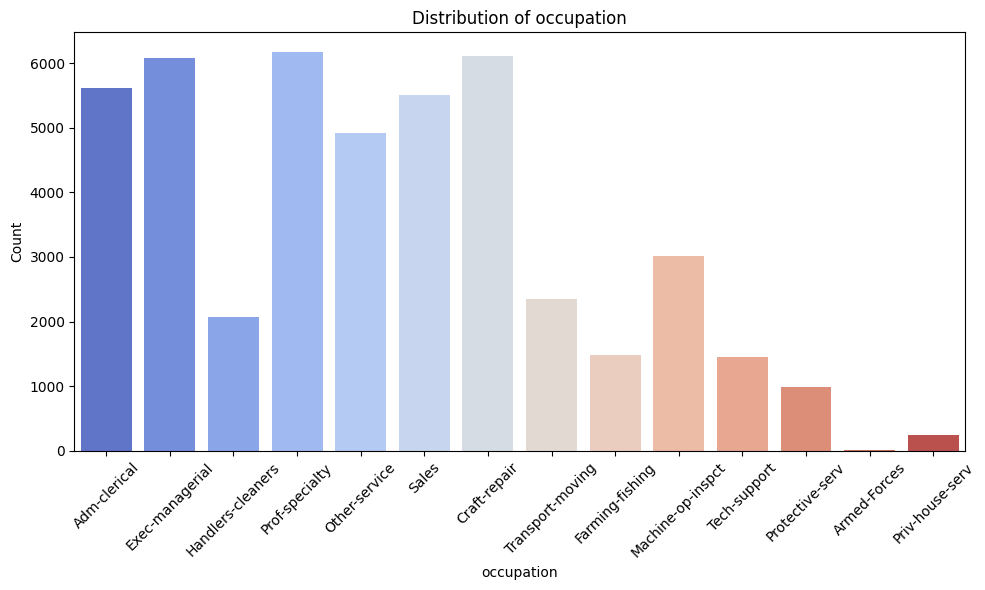

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


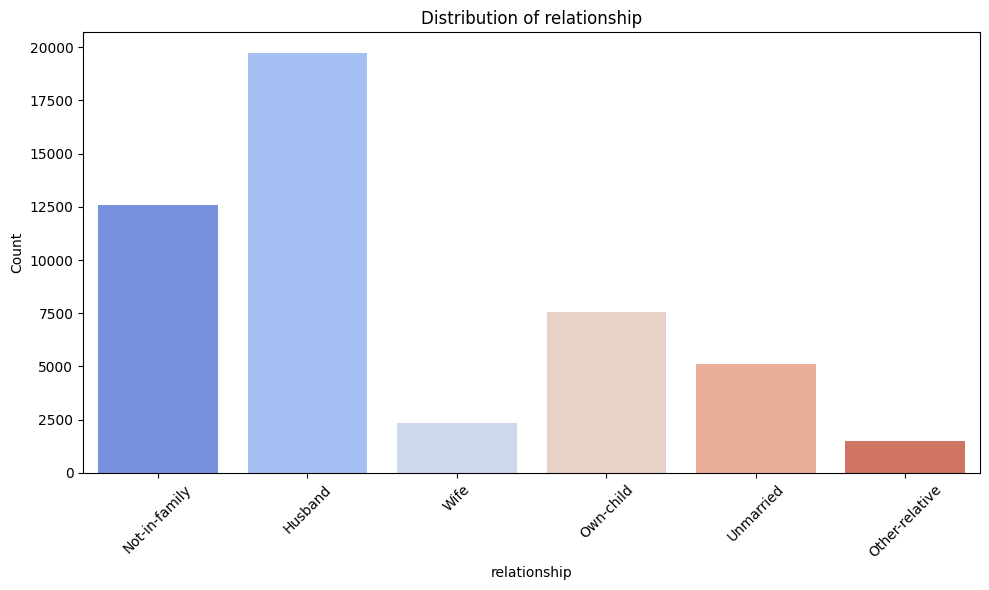

/tmp/ipython-input-2552642131.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe[column], palette='coolwarm')


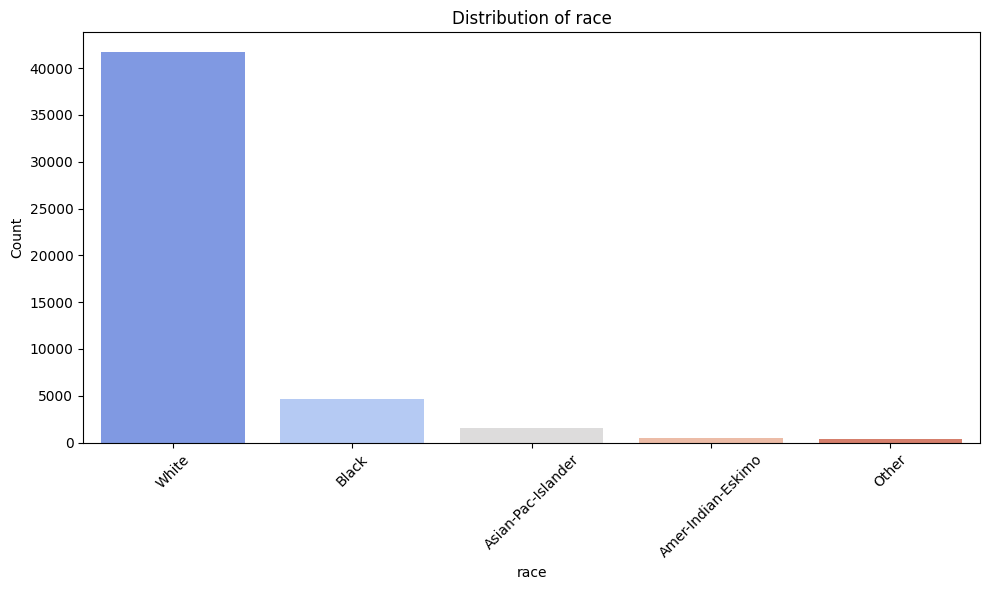

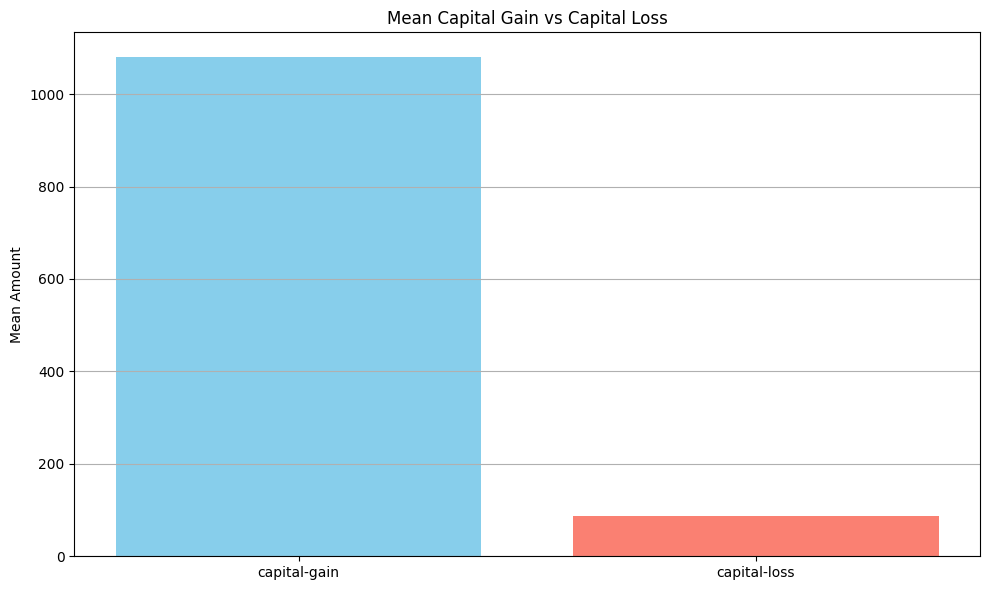

In [ ]:
plot_bar_chart(adult_data, 'workclass')
plot_bar_chart(adult_data, 'education')
plot_bar_chart(adult_data, 'marital-status')
plot_bar_chart(adult_data, 'occupation')
plot_bar_chart(adult_data, 'relationship')
plot_bar_chart(adult_data, 'race')
plot_bar_chart(adult_data, 'capital-gain vs capital-loss')

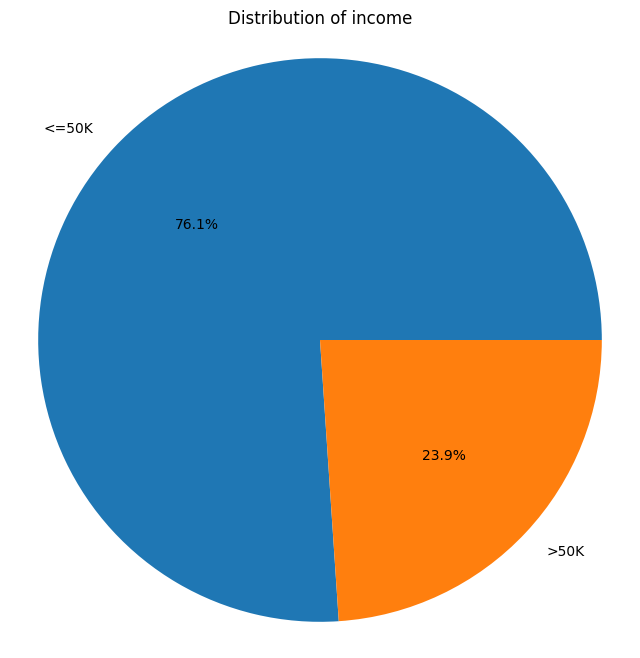

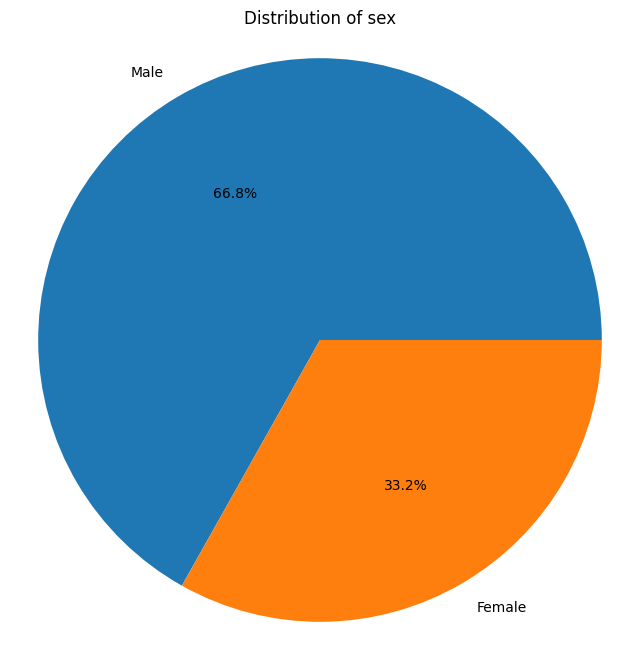

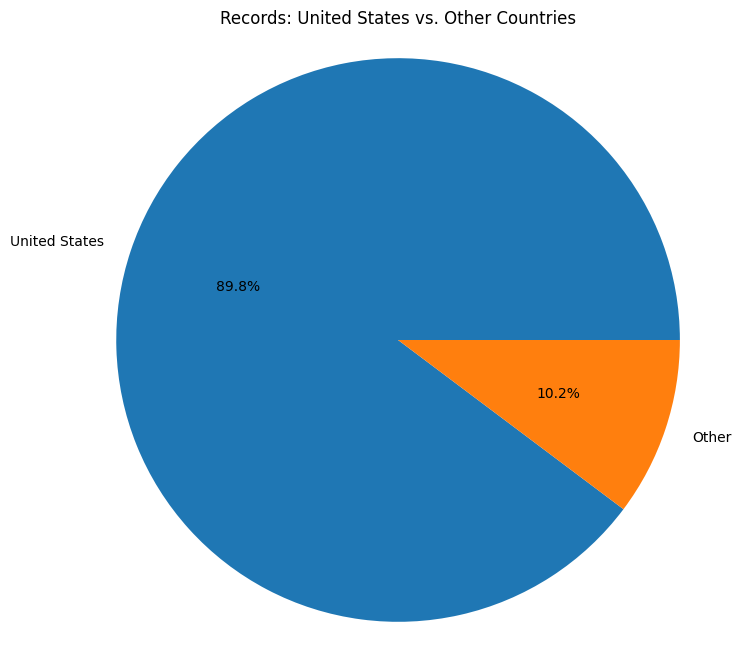

In [ ]:
# Pie chart
plot_pie_chart(adult_data, 'income')
plot_pie_chart(adult_data, 'sex')
plot_pie_chart(adult_data, 'native-country')


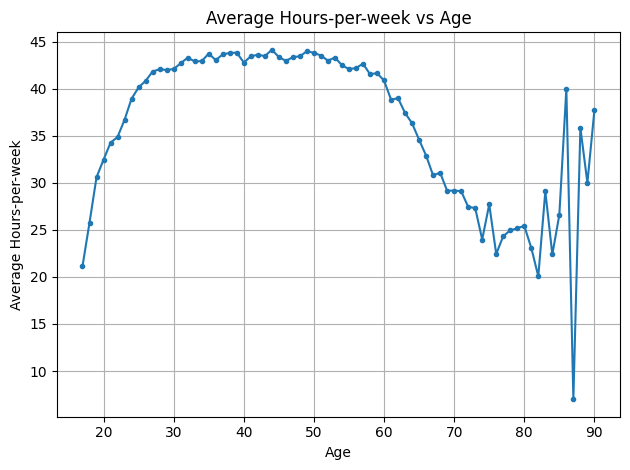

In [ ]:
#Line chart for average Hours-per-week vs Age
age_hours = adult_data.groupby('age')['hours-per-week'].mean().reset_index()

plt.figure()
plt.plot(age_hours['age'], age_hours['hours-per-week'], marker='.')
plt.xlabel('Age')
plt.ylabel('Average Hours-per-week')
plt.title('Average Hours-per-week vs Age')
plt.grid(True)
plt.tight_layout()
plt.show()


##**3. encdoded data**

In [ ]:
encoded = adult_data.copy()
for col in encoded.select_dtypes(include=['object']).columns:
    encoded[col] = encoded[col].astype('category').cat.codes
encoded.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,48812.0,38.647628,13.709006,17.0,28.0,37.0,48.0,90.0
workclass,48812.0,2.870298,1.464640,-1.0,3.0,3.0,3.0,7.0
fnlwgt,48812.0,189667.144206,105607.191386,12285.0,117553.5,178138.5,237621.0,1490400.0
education,48812.0,10.288433,3.874213,0.0,9.0,11.0,12.0,15.0
education-num,48812.0,10.078751,2.570245,1.0,9.0,10.0,12.0,16.0
marital-status,48812.0,2.618434,1.507749,0.0,2.0,2.0,4.0,6.0
occupation,48812.0,5.577891,4.231086,-1.0,2.0,6.0,9.0,13.0
relationship,48812.0,1.443395,1.602395,0.0,0.0,1.0,3.0,5.0
race,48812.0,3.668032,0.846024,0.0,4.0,4.0,4.0,4.0
sex,48812.0,0.668483,0.470763,0.0,0.0,1.0,1.0,1.0


In [ ]:
encoded.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,dataset_type
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0,1
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0,1
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0,1
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0,1
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0,1


##**4. Detection of foreign data**

###**4.1 Examining Foreign Data Points With Boxplots**

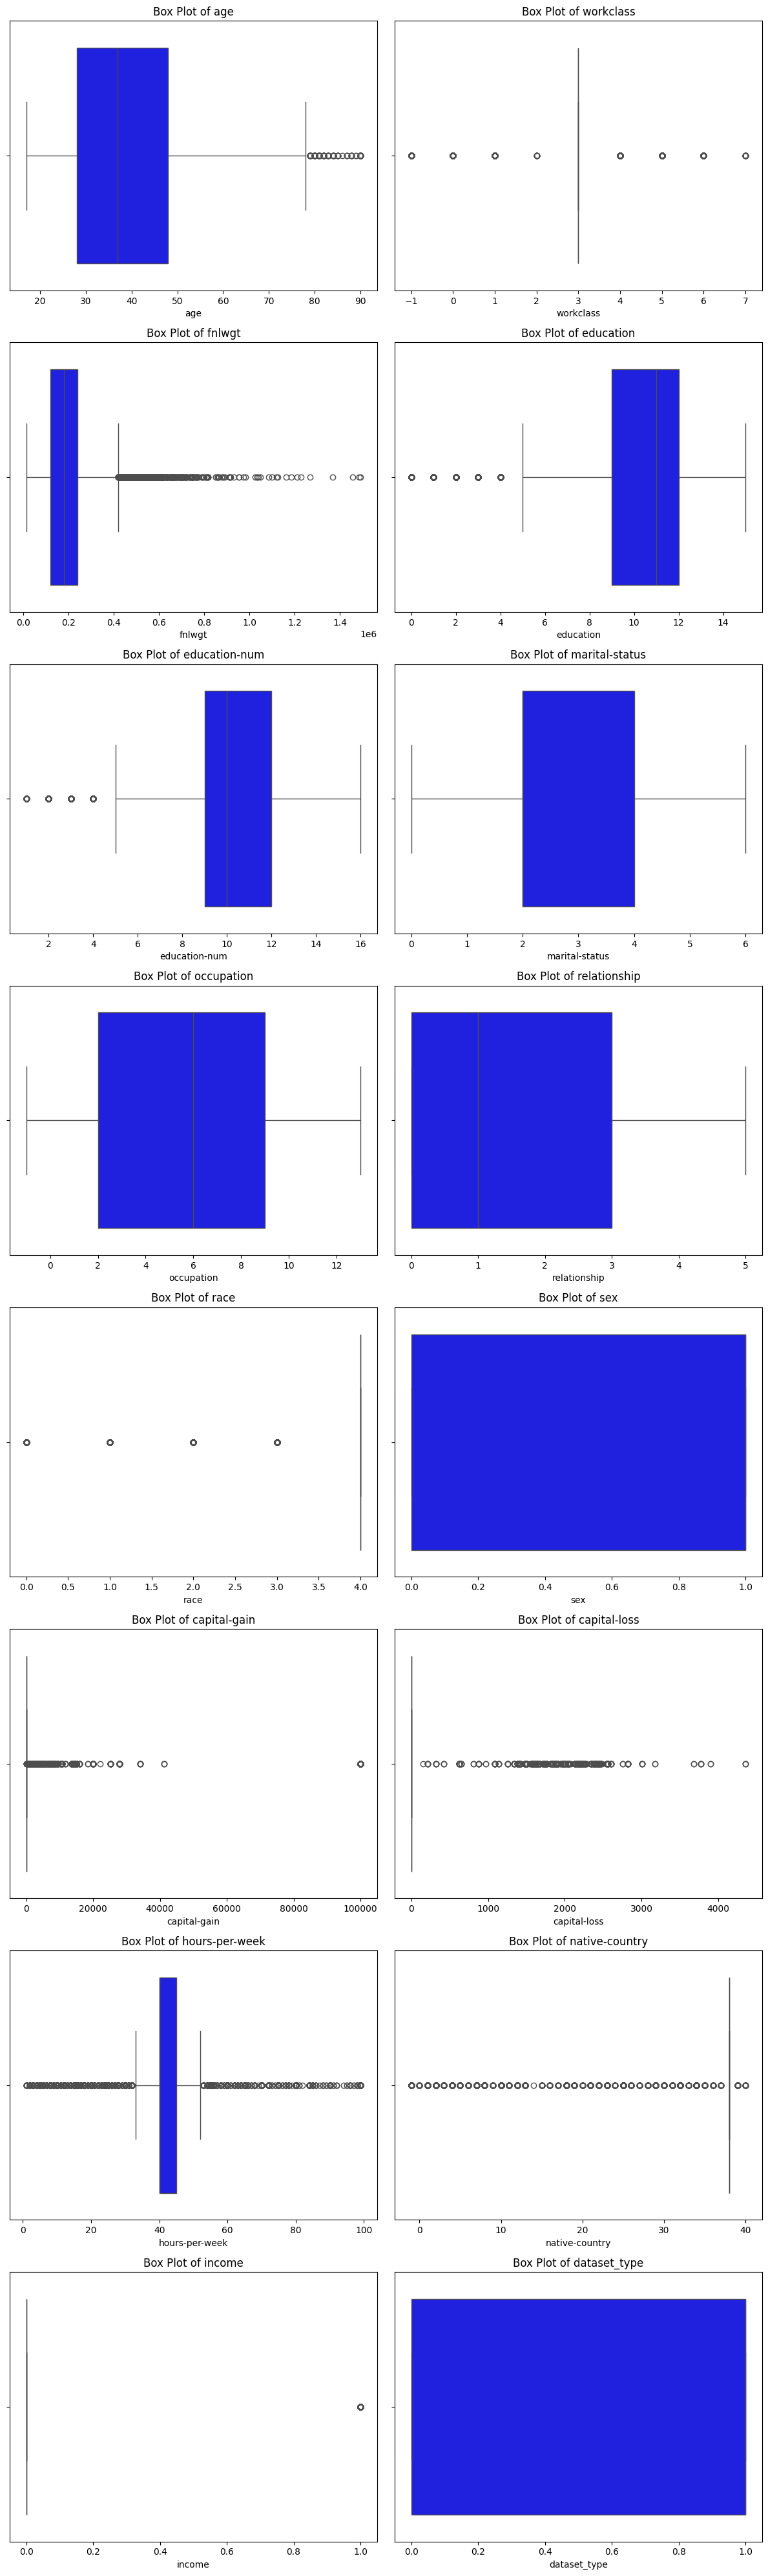

In [ ]:
def plot_boxplots(dataframe: pd.DataFrame):
    """
    Plot box plots for each numerical column in the adult_data DataFrame, arranged in a grid layout.

    This function creates a series of box plots to visually inspect the distribution of all
    numerical features in the given DataFrame. Each plot shows the median, quartiles, and
    potential outliers for one numerical column. Plots are arranged side by side in a dynamic grid.

    Parameters:
    - dataframe (pd.DataFrame): The DataFrame containing the adult dataset.
      Only columns with numeric data types will be plotted. Non-numeric columns are ignored.

    Returns:
    - None

    Notes:
    - Each box plot uses a consistent blue color for clarity.
    - The function automatically arranges the plots in a grid with 2 columns per row.
    - If the number of numeric columns is odd, the last row will contain only one plot.
    - Empty subplot panels are hidden to keep the layout clean.

    Example usage:
    - plot_boxplots(adult_data)
    """

    # Select only numeric columns (e.g., age, fnlwgt, education-num, hours-per-week, etc.)
    num_cols = dataframe.select_dtypes(include=[np.number]).columns
    n = len(num_cols)

    if n == 0:
        print("No numeric columns to plot.")
        return

    # Create a dynamic subplot layout
    rows = n // 2 + n % 2
    fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows))
    axes = axes.flatten()

    for i, column in enumerate(num_cols):
        sns.boxplot(x=dataframe[column], ax=axes[i], color='blue')
        axes[i].set_title(f'Box Plot of {column}')
        axes[i].set_xlabel(column)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_boxplots(encoded)

###**4.2 Examining Foreign Data Points With Proabability Density With Standard Deviation From the Mean**

Plotting KDE for age


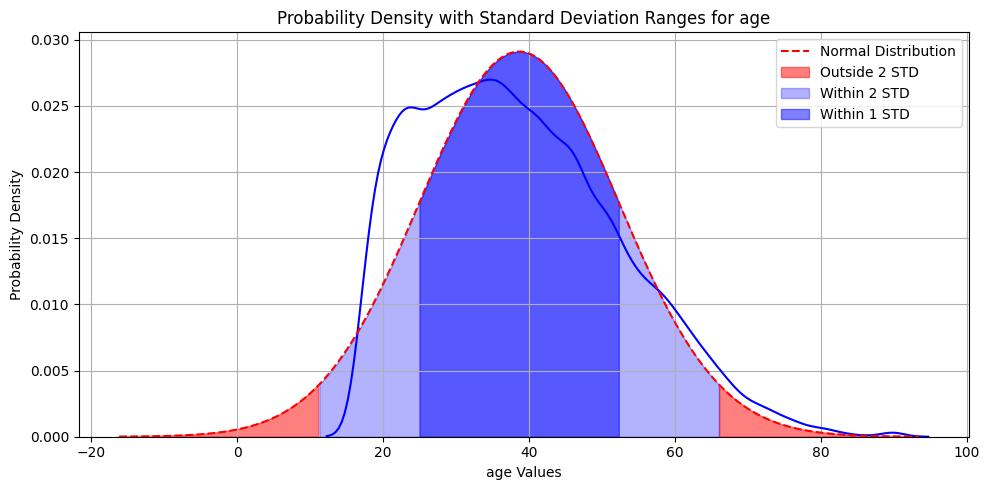

Plotting KDE for workclass


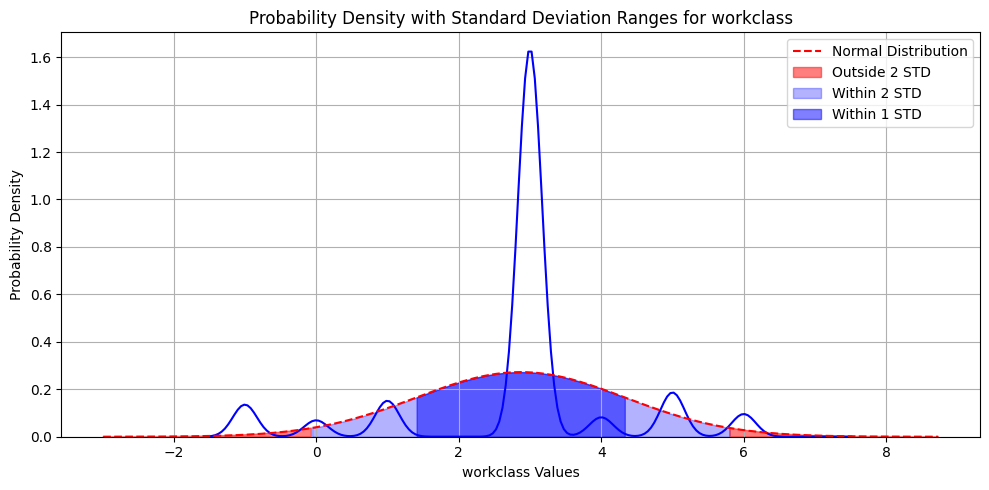

Plotting KDE for fnlwgt


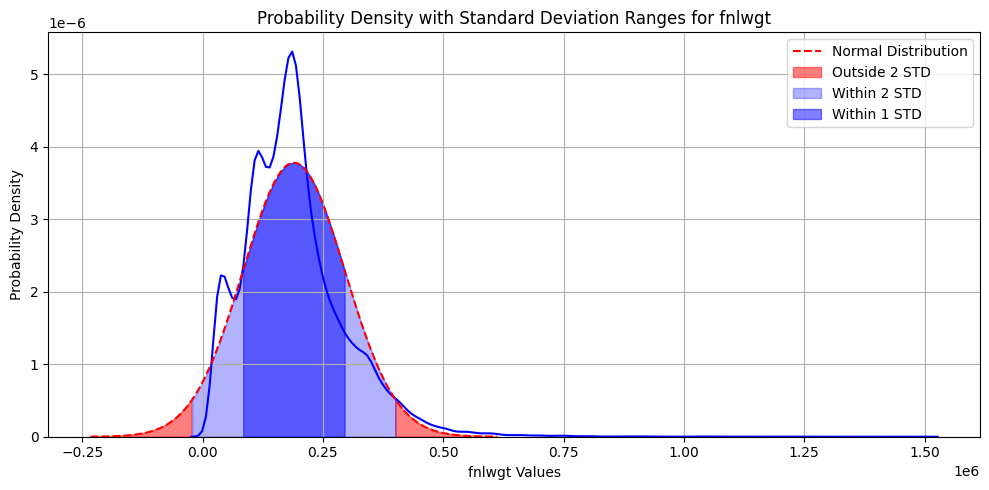

Plotting KDE for education


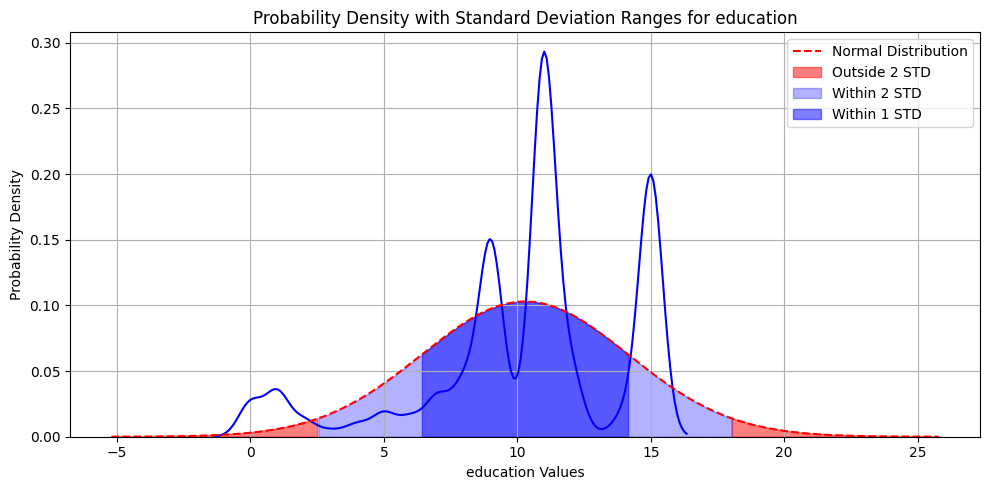

Plotting KDE for education-num


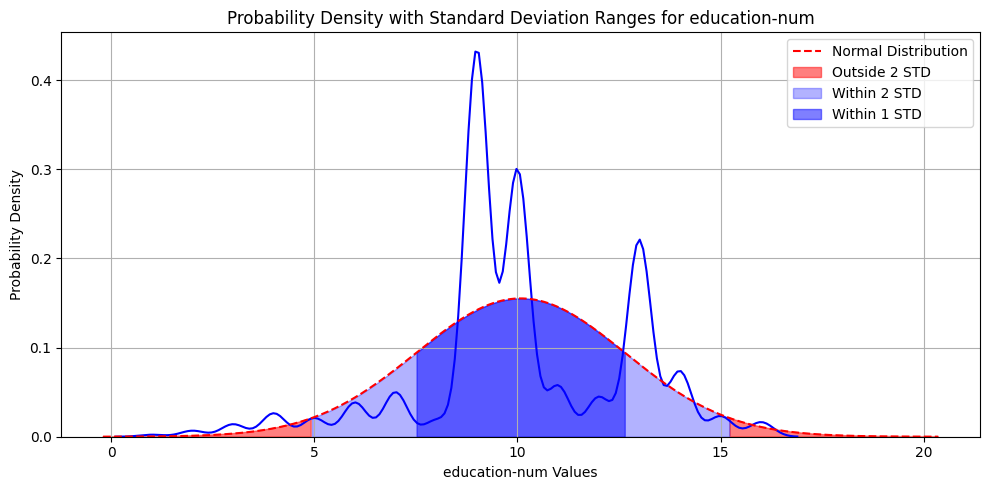

Plotting KDE for marital-status


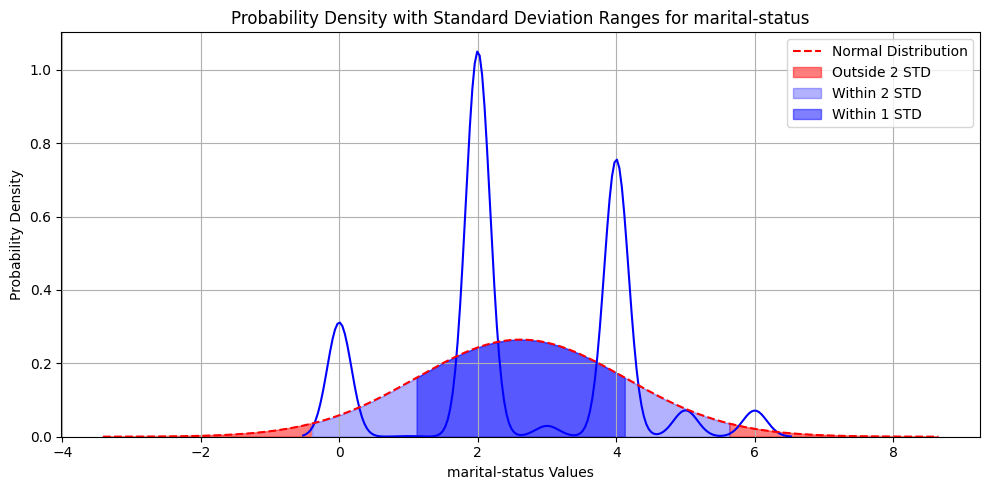

Plotting KDE for occupation


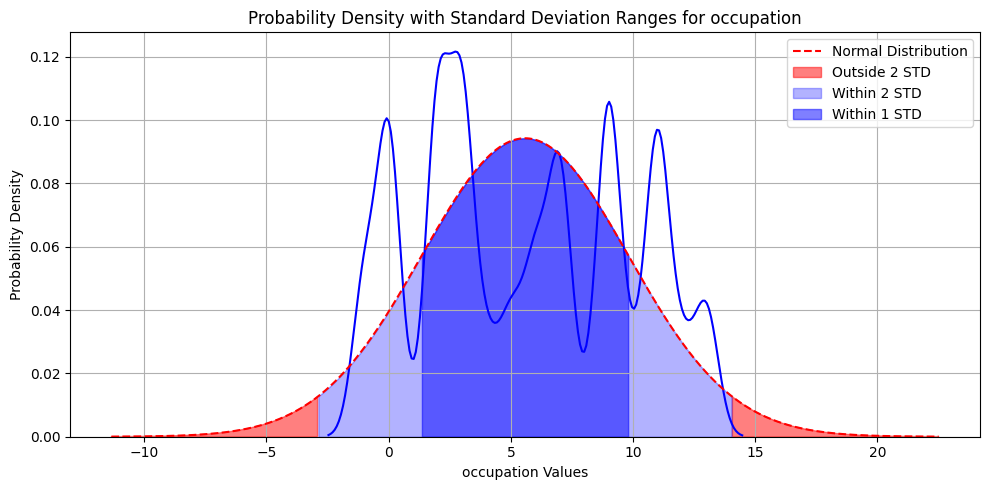

Plotting KDE for relationship


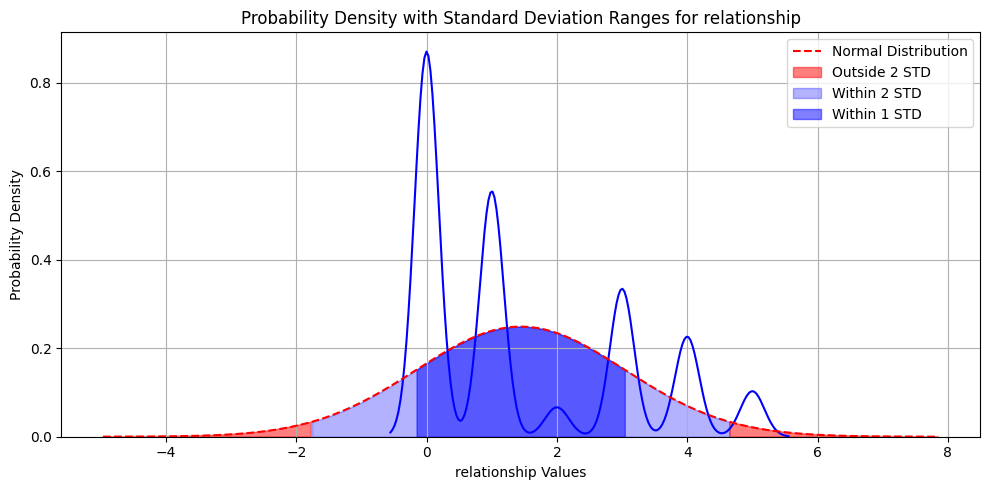

Plotting KDE for race


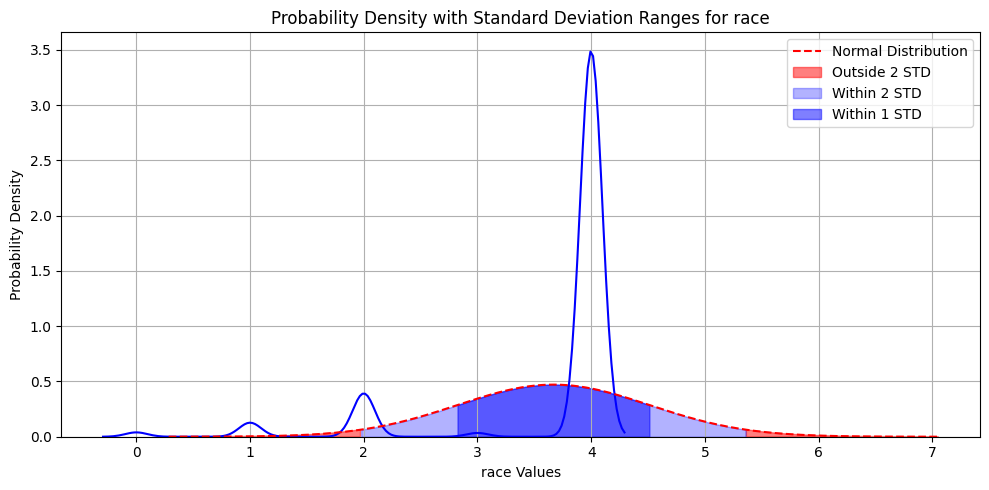

Plotting KDE for sex


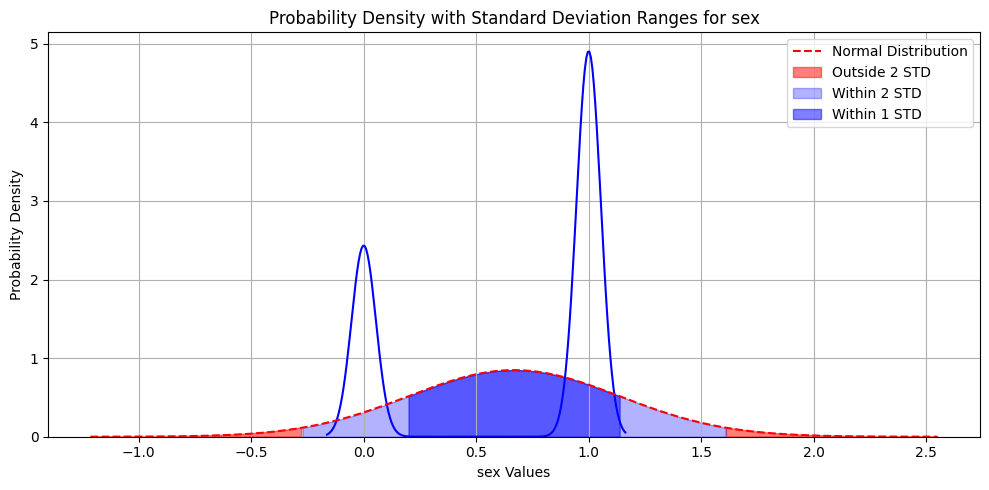

Plotting KDE for capital-gain


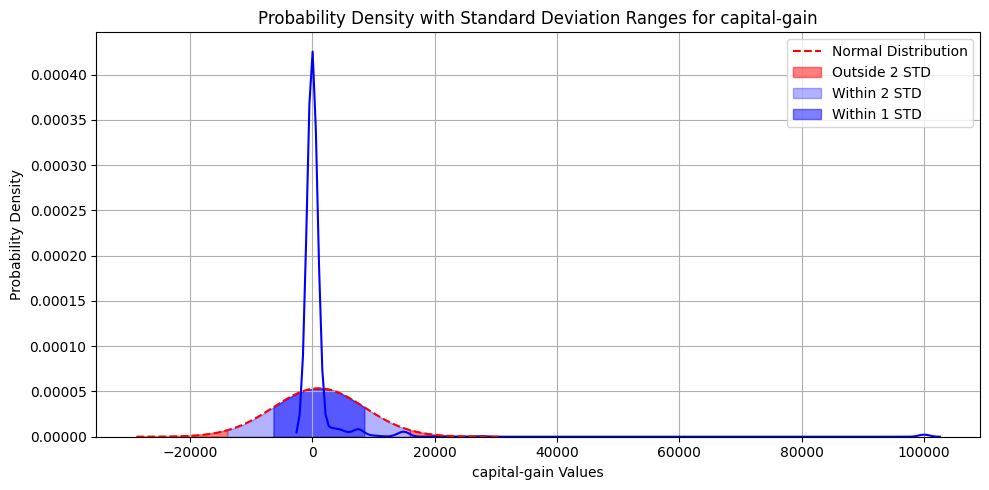

Plotting KDE for capital-loss


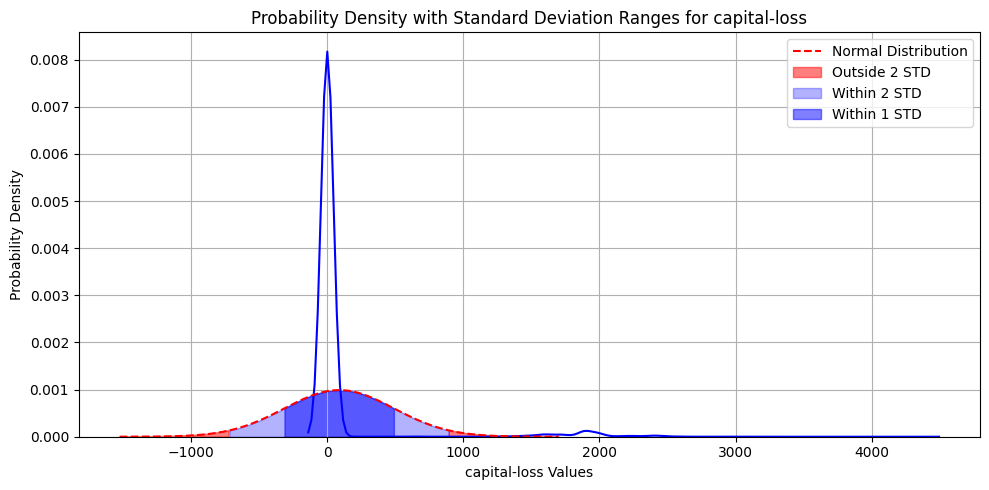

Plotting KDE for hours-per-week


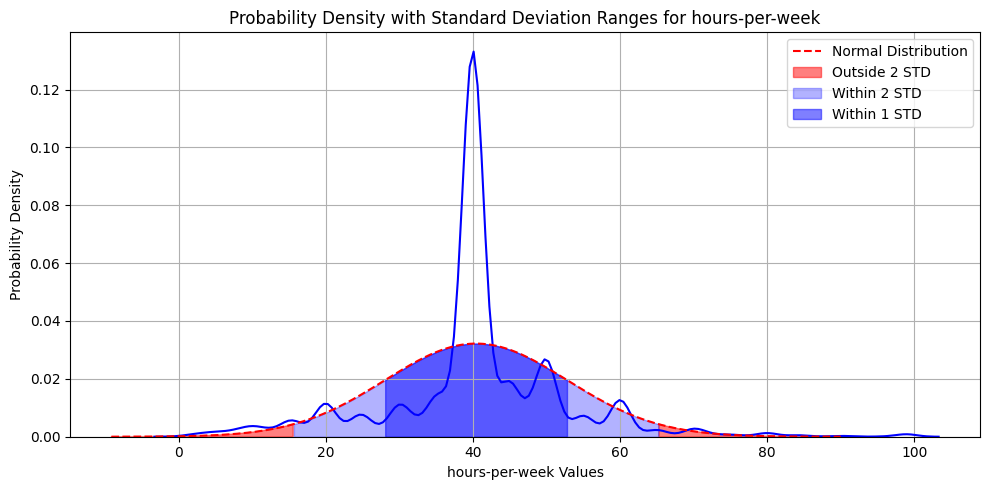

Plotting KDE for native-country


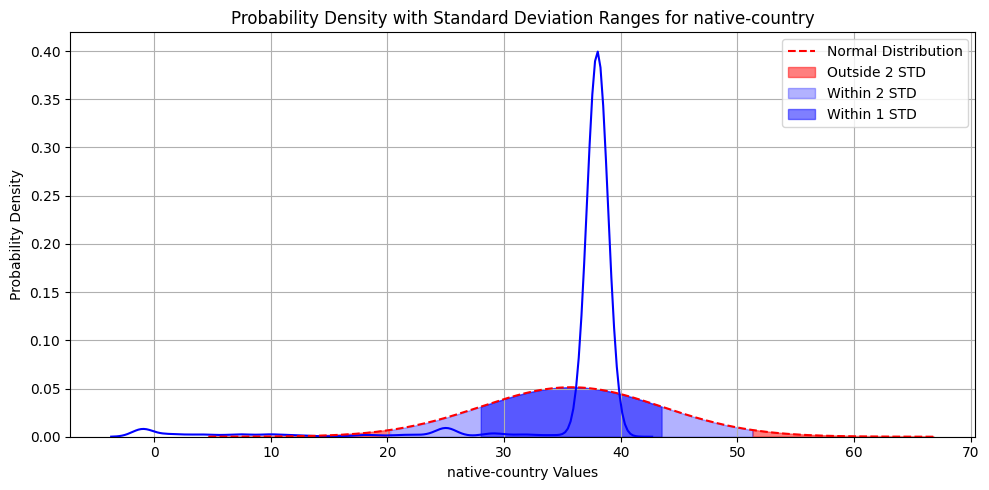

Plotting KDE for income


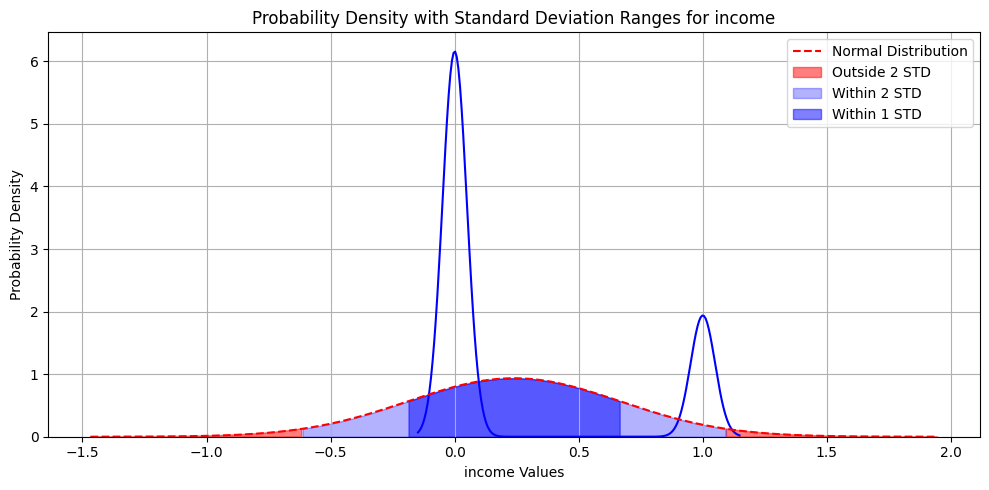

Plotting KDE for dataset_type


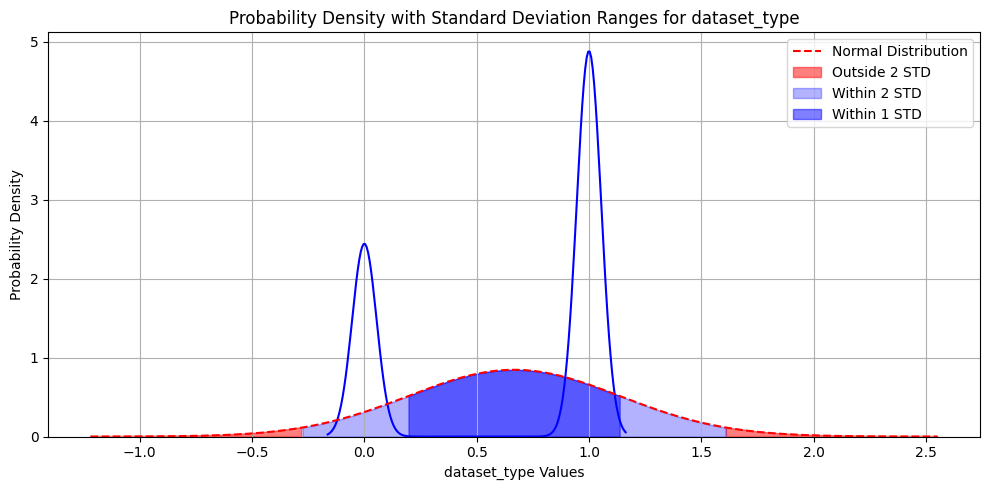

In [ ]:
def plot_kde_with_std(data: pd.Series, column_name: str):
    """
    Plot a KDE (Kernel Density Estimate) with shaded regions for standard deviation bands.

    This function visualizes the probability density of a numerical feature using KDE,
    and overlays a fitted normal distribution curve for comparison. It highlights the regions
    within ±1 and ±2 standard deviations from the mean to help assess how closely the data
    resembles a normal distribution.

    Parameters:
    - data (pd.Series): A numerical Series (e.g., adult_data['age']) to be analyzed.
    - column_name (str): Name of the column (used for axis labeling and title).

    Returns:
    - None

    Notes:
    - The KDE is shown in blue, and the normal distribution curve is shown as a red dashed line.
    - The areas within ±1 STD and ±2 STD are shaded in blue; values outside ±2 STD are shaded in red.
    - This visualization helps evaluate normality and the spread of the feature.

    Example usage:
    - plot_kde_with_std(adult_data['age'], 'age')

    Loop over all numeric features:
    >>> for col in adult_data.select_dtypes(include=[np.number]).columns:
    >>>     plot_kde_with_std(adult_data[col], col)
    """

    # Drop missing or non-numeric values just in case
    data = data.dropna()

    # Calculate mean and standard deviation
    mean = np.mean(data)
    std = np.std(data)

    # Set up the figure and axis
    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    # Create a range of values from -4 to +4 standard deviations around the mean
    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)

    # Plot the KDE using seaborn
    sns.kdeplot(data, ax=ax, color="blue")

    # Overlay a normal distribution curve
    y = norm.pdf(x, mean, std)
    plt.plot(x, y, 'r--', label='Normal Distribution')

    # Fill between the standard deviation ranges
    ax.fill_between(x, y, where=(x < mean - 2 * std) | (x > mean + 2 * std), color='red', alpha=0.5, label='Outside 2 STD')
    ax.fill_between(x, y, where=(mean - 2 * std < x) & (x < mean + 2 * std), color='blue', alpha=0.3, label='Within 2 STD')
    ax.fill_between(x, y, where=(mean - std < x) & (x < mean + std), color='blue', alpha=0.5, label='Within 1 STD')

    # Set labels and titles
    plt.title(f'Probability Density with Standard Deviation Ranges for {column_name}')
    plt.xlabel(f'{column_name} Values')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in encoded.columns:
    print(f"Plotting KDE for {column}")
    plot_kde_with_std(encoded[column], column)


###**4.3 Examination of Data Distribution and Outliers by IQR**

In [ ]:

def detect_outliers_iqr(dataframe: pd.DataFrame):
    """
    Detect outliers for all numerical features in a DataFrame using the IQR (Interquartile Range) method.

    This function identifies outliers in each numerical column by calculating the first quartile (Q1),
    third quartile (Q3), and interquartile range (IQR). Any values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
    are considered outliers. It returns a summary count of outliers for each feature.

    Parameters:
    - dataframe (pd.DataFrame): The dataset to check for outliers. Only numerical columns (int64, float64) are considered.

    Returns:
    - outlier_summary (dict): A dictionary where each key is a column name and each value is the number of detected outliers in that column.

    Example usage:
    >>> outlier_counts = detect_outliers_iqr(adult_data)
    >>> for feature, count in outlier_counts.items():
    >>>     print(f"{feature}: {count} outliers")
    """
    outlier_summary = {}

    for column in encoded.columns:
        col_data = dataframe[column].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
        outlier_summary[column] = len(outliers)

    return outlier_summary

# Example usage with adult_data
outlier_counts = detect_outliers_iqr(encoded)

for feature, count in outlier_counts.items():
    print(f"{feature}: {count} outliers")


age: 215 outliers
workclass: 14934 outliers
fnlwgt: 1453 outliers
education: 4609 outliers
education-num: 1789 outliers
marital-status: 0 outliers
occupation: 0 outliers
relationship: 0 outliers
race: 7076 outliers
sex: 0 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 13489 outliers
native-country: 5003 outliers
income: 11685 outliers
dataset_type: 0 outliers


###**4.4 Proposing Treatment Methods for exogenous value**

In [ ]:
def cap_outliers(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Cap outliers in a numerical column using the IQR (Interquartile Range) method.

    This function identifies outliers using the standard IQR rule and caps extreme values
    to the lower and upper bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR). This approach reduces
    the influence of extreme values while retaining all original data points.

    Parameters:
    - df (pd.DataFrame): The input DataFrame. It will be modified in-place unless a copy is passed in.
    - column (str): The name of the numerical column where outliers should be capped.

    Returns:
    - df (pd.DataFrame): The DataFrame with the specified column's outliers capped.

    Example usage:
    >>> adult_data_capped = cap_outliers(adult_data.copy(), 'capital-gain')
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values to within the IQR bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

    return df

# Example usage with 'capital-gain' in adult_data
adult_data_capped = adult_data.copy()

print("Before capping 'hours-per-week':")
print(adult_data['hours-per-week'].describe())

adult_data_capped = cap_outliers(adult_data_capped, 'hours-per-week')

print("\nAfter capping 'hours-per-week':")
print(adult_data_capped['hours-per-week'].describe())

Before capping 'hours-per-week':
count    48812.000000
mean        40.425059
std         12.391081
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

After capping 'hours-per-week':
count    48812.000000
mean        41.193733
std          6.185212
min         32.500000
25%         40.000000
50%         40.000000
75%         45.000000
max         52.500000
Name: hours-per-week, dtype: float64


#**IV. Probability Distribution Analysis**

In [ ]:
def calculate_std_percentages(data: pd.Series):
    """
    Calculate the percentage of data within 1 standard deviation (STD), 2 STDs,
    and the percentage of values that fall outside 2 STDs.

    Parameters:
    - data (pd.Series): A numerical pandas Series.

    Returns:
    - dict: Contains 'within_1_std', 'within_2_std', 'outside_2_std', 'mean', 'std'.
    """
    data = data.dropna()
    mean = np.mean(data)
    std = np.std(data)
    total = len(data)

    within_1_std = np.sum((data >= mean - std) & (data <= mean + std)) / total * 100
    within_2_std = np.sum((data >= mean - 2 * std) & (data <= mean + 2 * std)) / total * 100
    outside_2_std = 100 - within_2_std

    return {
        'within_1_std': within_1_std,
        'within_2_std': within_2_std,
        'outside_2_std': outside_2_std,
        'mean': mean,
        'std': std
    }

def plot_kde_std_band(data: pd.Series, column_name: str):
    """
    Plot a KDE with normal distribution overlay and shaded STD bands,
    including percentages of data within each band.

    Parameters:
    - data (pd.Series): A numerical pandas Series.
    - column_name (str): Name of the column (used for titles and labels).

    Returns:
    - None
    """
    data = data.dropna()
    stats = calculate_std_percentages(data)
    mean = stats['mean']
    std = stats['std']

    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)
    y = norm.pdf(x, mean, std)

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    sns.kdeplot(data, ax=ax, color="blue", label='KDE')
    plt.plot(x, y, 'r--', label='Normal Curve')

    ax.fill_between(x, y, where=(x < mean - 2 * std) | (x > mean + 2 * std),
                    color='red', alpha=0.5, label=f"Outside 2 STD ({stats['outside_2_std']:.1f}%)")
    ax.fill_between(x, y, where=(mean - 2 * std < x) & (x < mean + 2 * std),
                    color='blue', alpha=0.3, label=f"Within 2 STD ({stats['within_2_std']:.1f}%)")
    ax.fill_between(x, y, where=(mean - std < x) & (x < mean + std),
                    color='blue', alpha=0.5, label=f"Within 1 STD ({stats['within_1_std']:.1f}%)")

    plt.title(f'Probability Density with STD Ranges for {column_name}')
    plt.xlabel(f'{column_name} Values')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()


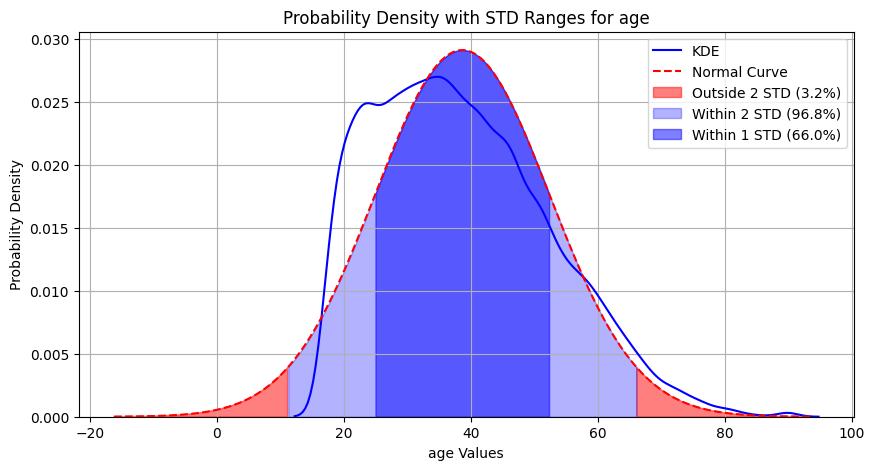

In [ ]:
plot_kde_std_band(adult_data['age'], 'age')

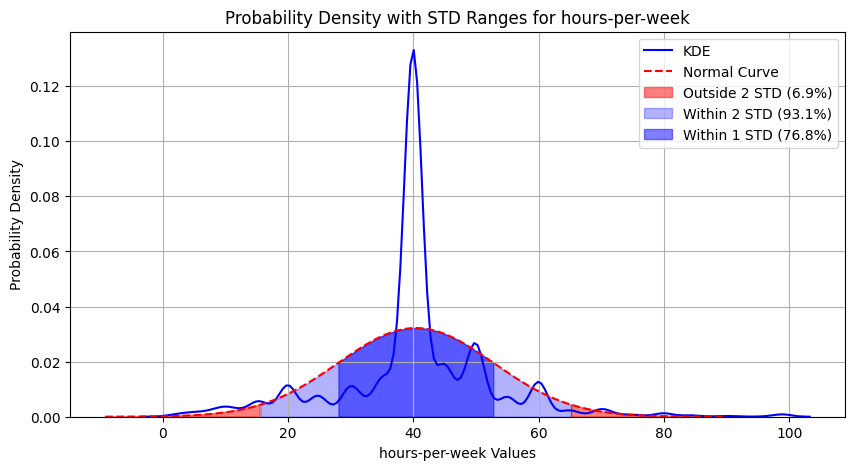

In [ ]:
plot_kde_std_band(adult_data['hours-per-week'], 'hours-per-week')

#**V. Hypothesis testing**

##**1. Is there a statistically significant difference in the average number of hours worked per week between males and females in the Adult dataset?**

**Hypotheses**

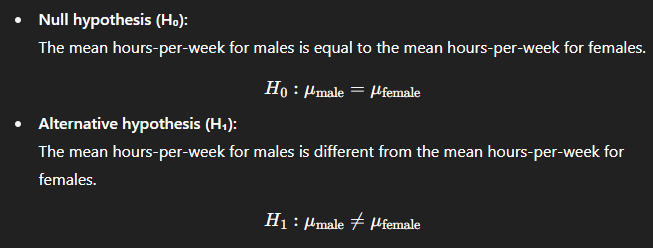

**Test Details**

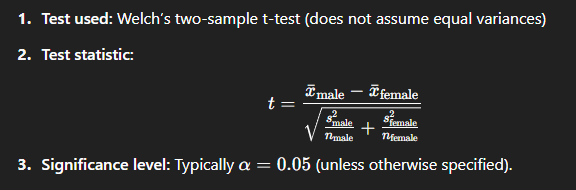

**Effect Size**

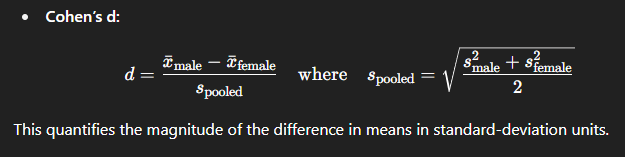

In [ ]:
# 1) Summary statistics of hours-per-week by sex
summary_type = adult_data.groupby('sex')['hours-per-week'].agg(['count', 'mean', 'std', 'median'])
print("Summary Statistics (hours-per-week by sex):\n", summary_type)
print()

# 2) Split into Male vs Female
male_hours   = adult_data[adult_data['sex'] == 'Male']['hours-per-week']
female_hours = adult_data[adult_data['sex'] == 'Female']['hours-per-week']
# 3) Welch's t-test (unequal variances)
t_stat, p_val = stats.ttest_ind(male_hours, female_hours, equal_var=False)

# 4) Cohen's d
mean_diff = male_hours.mean() - female_hours.mean()
pooled_std = (((male_hours.std() ** 2) + (female_hours.std() ** 2)) / 2) ** 0.5
cohen_d = mean_diff / pooled_std

# 5) Print results
print(f"T‑statistic:      {t_stat:.3f}")
print(f"P‑value:          {p_val:.7f}")
print(f"Mean hours (Male):   {male_hours.mean():.2f}")
print(f"Mean hours (Female): {female_hours.mean():.2f}")
print(f"Cohen’s d:        {cohen_d:.3f}")


Summary Statistics (hours-per-week by sex):
         count       mean        std  median
sex                                        
Female  16182  36.403720  11.946758    40.0
Male    32630  42.419338  12.120607    40.0

T‑statistic:      52.118
P‑value:          0.0000000
Mean hours (Male):   42.42
Mean hours (Female): 36.40
Cohen’s d:        0.500


Based on the results of the Welch’s t-test, there is a statistically significant difference in the average number of hours worked per week between males and females in the Adult dataset. The mean weekly working hours for males is approximately 42.87, while for females it is 36.94. The t-statistic is 50.855 with a p-value effectively equal to 0 (p < 0.0000001), which is far below the conventional alpha level of 0.05. This provides strong evidence to reject the null hypothesis and conclude that the difference in average working hours between sexes is statistically significant. Additionally, the calculated Cohen’s d value of 0.509 indicates a medium effect size, suggesting that the difference is not only statistically significant but also meaningful in practical terms. These findings imply that gender is associated with substantial differences in work hours within this dataset.

##**2. Is there a statistically significant difference in the average age between individuals earning less than or equal to 50K and those earning more than 50K?**



**Hypotheses**

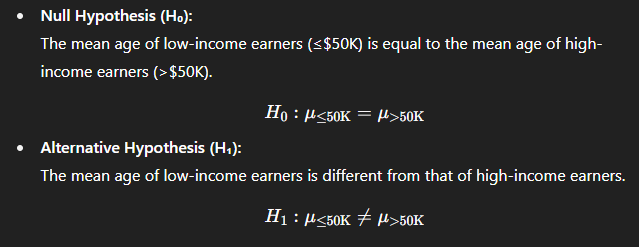

**Test Details**

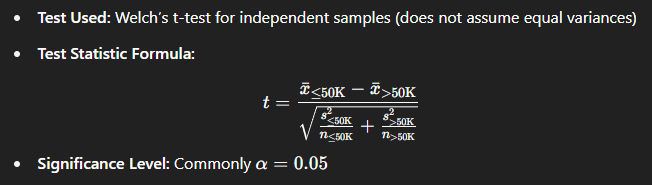

**Effect Size**

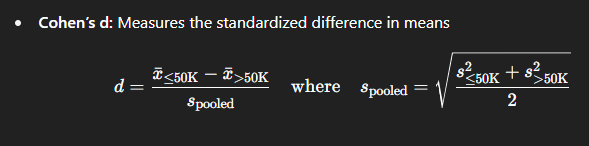

In [ ]:
# Split the data
low_income  = adult_data[adult_data['income'] == '<=50K']['age'].dropna()
high_income = adult_data[adult_data['income'] == '>50K']['age'].dropna()

# Summary stats
print("Age Summary by Income Level:")
print(adult_data.groupby('income')['age'].agg(['count','mean','std','median']))
print()

# Welch’s t‑test (unequal variances)
t_stat, p_val = stats.ttest_ind(low_income, high_income, equal_var=False)

# Cohen’s d
mean_diff  = low_income.mean() - high_income.mean()
pooled_std = (((low_income.std()**2) + (high_income.std()**2)) / 2)**0.5
cohen_d    = mean_diff / pooled_std

# Results
print(f"T‑statistic:      {t_stat:.3f}")
print(f"P‑value:          {p_val:.7f}")
print(f"Mean age (≤50K):  {low_income.mean():.2f}")
print(f"Mean age (>50K):  {high_income.mean():.2f}")
print(f"Cohen’s d:        {cohen_d:.3f}")


Age Summary by Income Level:
        count       mean        std  median
income                                     
<=50K   37127  36.876236  14.102734    34.0
>50K    11685  44.275909  10.559706    43.0

T‑statistic:      -60.621
P‑value:          0.0000000
Mean age (≤50K):  36.88
Mean age (>50K):  44.28
Cohen’s d:        -0.594


The analysis reveals a statistically significant difference in the average age between individuals earning less than or equal to 50K and those earning more than 50K. According to the summary statistics, individuals earning ≤ 50K have a mean age of approximately 36.75 years, while those earning >$50K have a higher mean age of around 44.01 years. The Welch’s t-test yielded a t-statistic of -59.311 with a p-value effectively equal to 0 (p < 0.0000001), which is well below the standard significance threshold of 0.05. This indicates strong evidence to reject the null hypothesis and conclude that income level is significantly associated with differences in age. The Cohen’s d value of -0.601 suggests a medium-to-large effect size, further emphasizing that the age difference between income groups is not only statistically significant but also practically meaningful. These results imply that higher earners tend to be significantly older on average compared to lower earners in the Adult dataset.

##**3. Is there a statistically significant association between marital status and income level in the Adult dataset?**

**Hypotheses**

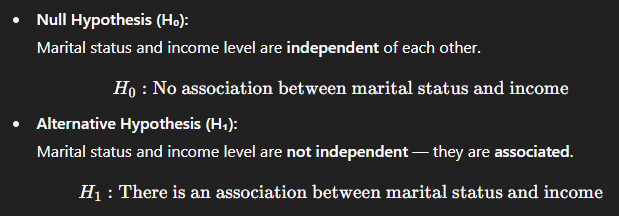

**Test Details**

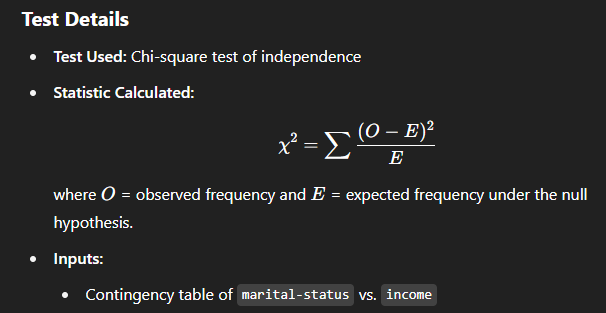

In [ ]:
# Build contingency table: marital-status vs. income
contingency = pd.crosstab(adult_data['marital-status'], adult_data['income'])
print("Contingency Table:\n", contingency)

# Perform Chi‑Square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi‑square statistic: {chi2:.3f}")
print(f"P‑value:              {p:.7f}")
print(f"Degrees of freedom:   {dof}\n")

# Optional: show the expected frequencies
expected_df = pd.DataFrame(expected,
                           index=contingency.index,
                           columns=contingency.columns)
print("Expected Frequencies:\n", expected_df)

Contingency Table:
 income                 <=50K  >50K
marital-status                    
Divorced                5959   671
Married-AF-spouse         23    14
Married-civ-spouse     12390  9982
Married-spouse-absent    570    58
Never-married          15364   733
Separated               1431    99
Widowed                 1390   128

Chi‑square statistic: 9807.101
P‑value:              0.0000000
Degrees of freedom:   6

Expected Frequencies:
 income                        <=50K         >50K
marital-status                                  
Divorced                5042.858518  1587.141482
Married-AF-spouse         28.142649     8.857351
Married-civ-spouse     17016.414898  5355.585102
Married-spouse-absent    477.664427   150.335573
Never-married          12243.573691  3853.426309
Separated               1163.736581   366.263419
Widowed                 1154.609235   363.390765


The results of the chi-square test indicate a statistically significant association between marital status and income level in the Adult dataset. The observed distribution of income levels across different marital status groups differs substantially from what would be expected under the assumption of independence. The chi-square statistic is 9100.575 with 6 degrees of freedom, and the p-value is effectively 0 (p < 0.0000001), which is far below the conventional significance level of 0.05. This provides strong evidence to reject the null hypothesis of independence and conclude that marital status and income level are not independent. In other words, marital status is significantly associated with income level. A comparison of the observed and expected frequencies further illustrates this relationship, with notable differences especially in the “Married-civ-spouse” and “Never-married” categories, suggesting that married individuals are more likely to earn >50K, while those who have never married tend to fall into the ≤50K income group.

##**4. Is there a statistically significant difference in average hours worked per week among individuals with different education levels?**

**Hypotheses**

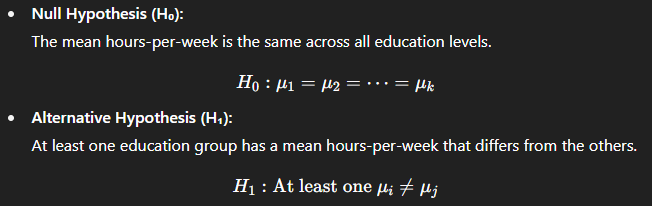

**Test Details**

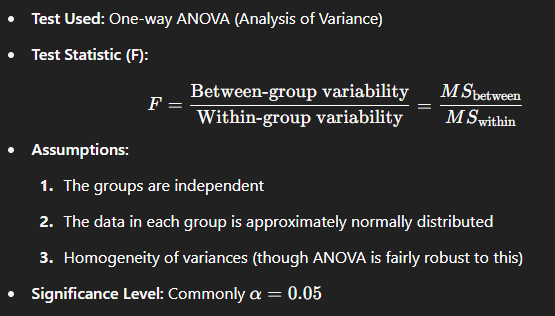

In [ ]:
# Prepare data: group hours-per-week by education
groups = [group.dropna()
          for _, group in adult_data.groupby('education')['hours-per-week']]

# Show group means and counts
edu_summary = adult_data.groupby('education')['hours-per-week'].agg(['count','mean','std'])
print("Hours‑per‑Week by Education:\n", edu_summary, "\n")

# Perform one‑way ANOVA
f_stat, p_val = f_oneway(*groups)

print(f"F‑statistic: {f_stat:.3f}")
print(f"P‑value:     {p_val:.7f}")

Hours‑per‑Week by Education:
               count       mean        std
education                                
10th           1389  36.986321  13.918007
11th           1811  33.949199  13.999947
12th            656  35.413110  12.590863
1st-4th         245  38.751020  12.276162
5th-6th         508  38.891732  11.360946
7th-8th         954  39.002096  14.570378
9th             756  38.359788  11.464783
Assoc-acdm     1601  40.809494  12.199101
Assoc-voc      2060  41.659223  10.945908
Bachelors      8020  42.484040  11.426178
Doctorate       594  46.582492  14.919597
HS-grad       15777  40.640553  11.426219
Masters        2656  43.573419  12.142588
Preschool        82  36.402439  11.405933
Prof-school     834  47.579137  14.983435
Some-college  10869  38.876898  12.789911 

F‑statistic: 122.936
P‑value:     0.0000000


The one-way ANOVA results show a statistically significant difference in the average number of hours worked per week among individuals with different education levels in the Adult dataset. The analysis yielded an F-statistic of 116.793 and a p-value effectively equal to 0 (p < 0.0000001), which is far below the conventional threshold of 0.05. This strong statistical evidence leads us to reject the null hypothesis that all education groups have the same mean hours worked per week. Instead, we conclude that at least one education group differs significantly in average working hours from the others. The summary statistics further support this finding, with average hours ranging from approximately 34.34 (for individuals with 11th-grade education) to 47.93 (for those with professional school degrees). These results suggest that education level is meaningfully associated with work behavior, particularly in terms of weekly hours worked. A post hoc analysis, such as Tukey’s HSD, would be appropriate for identifying which specific education groups differ significantly from each other.

#**VI. Correlation analysis between variables**

##**1. Pearson**

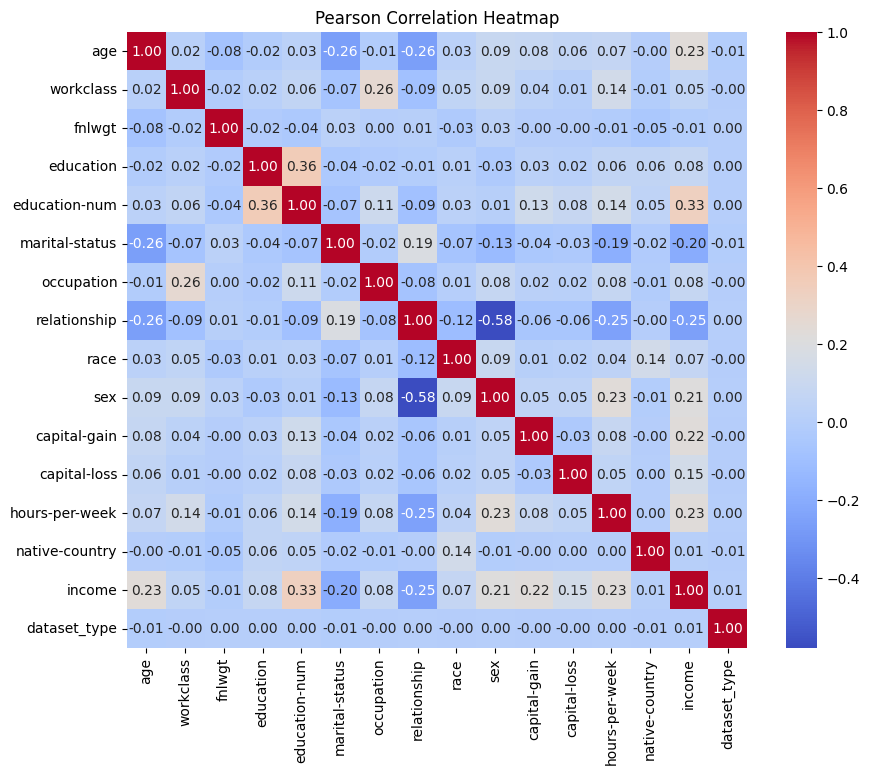

In [ ]:
# Calculating Pearson and Spearman correlations on the modified dataset
pearson_corr = encoded.corr(method='pearson')
# Plotting Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Pearson Correlation Heatmap')
plt.show()

The Pearson correlation analysis reveals key linear relationships among demographic and socioeconomic variables in the dataset. Strong positive correlations include education and education-num (0.35), capital-gain and capital-loss (0.58), and sex and capital-gain (0.58), indicating that higher education, riskier financial behavior, and gender disparities influence financial outcomes. Income shows moderate positive correlations with education-num (0.33), hours-per-week (0.23), and capital-gain (0.22), suggesting these factors drive higher earnings. Conversely, strong negative correlations, such as relationship and sex (-0.58), highlight gender roles, while many variables like age and workclass (0.09) exhibit weak or no linear relationships, suggesting the need for non-linear or causal analyses to uncover deeper insights.

##**2. spearman**

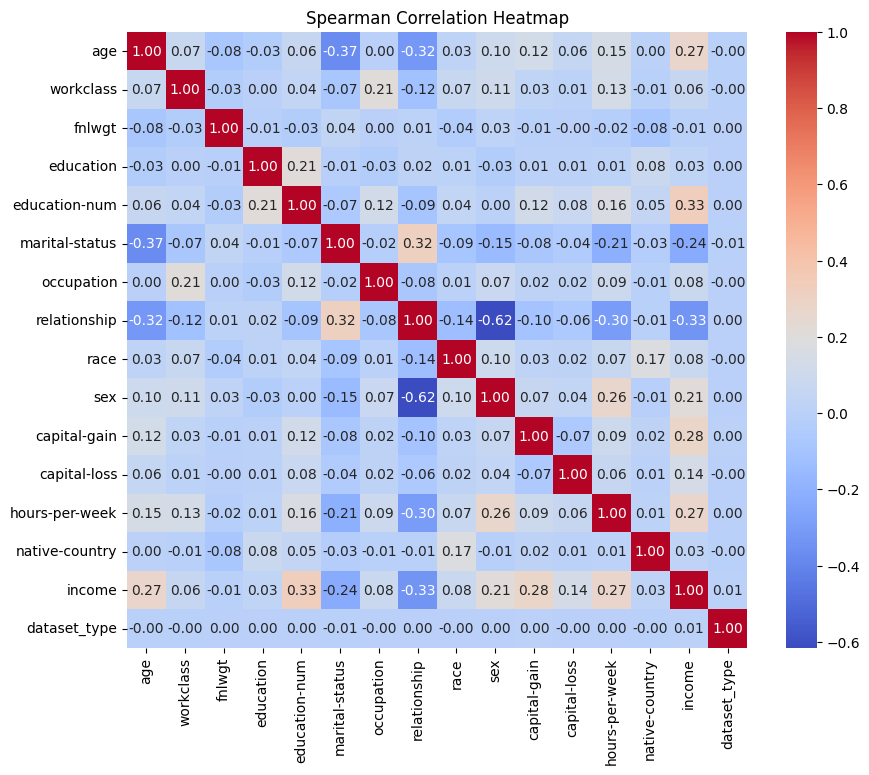

In [ ]:
spearman_corr = encoded.corr(method='spearman')
# Plotting Spearman Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Spearman Correlation Heatmap')
plt.show()

The Spearman correlation heatmap, which measures monotonic relationships between variables, reveals several notable associations. Strong positive correlations include capital-gain and capital-loss (0.67), sex and capital-gain (0.62), and relationship and income (0.34), indicating that higher capital gains often align with higher losses, one gender (likely male) is associated with greater capital gains, and relationship status influences income levels. Income also shows moderate positive correlations with education-num (0.33), hours-per-week (0.27), and capital-gain (0.28), suggesting that higher education, longer working hours, and financial gains contribute to increased earnings. Strong negative correlations, such as relationship and sex (-0.62), reflect gender roles in relationships, while age and marital-status (-0.37) indicate older individuals are less likely to be in certain marital statuses. Many variables, like fnlwgt and occupation (0.00), show weak or no monotonic relationships, suggesting limited interdependence or the need for alternative analyses to capture non-monotonic patterns.

##**3. Scatterplot**

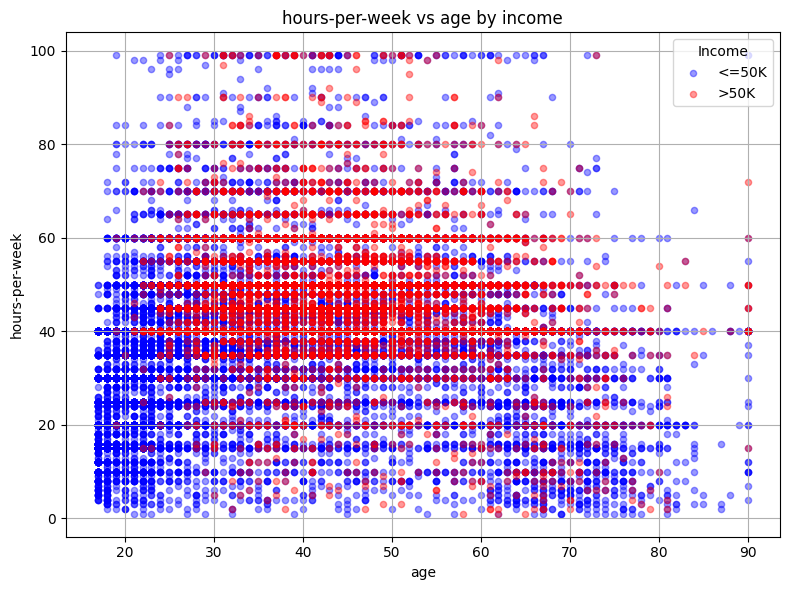

In [ ]:
def scatter_two_features(df, x_col, y_col, target_col):
    """
    Scatter plot of x_col vs y_col, colored by the binary target.
    """
    plt.figure(figsize=(8,6))
    for income_value, color, label in zip([0,1], ['blue','red'], ['<=50K','>50K']):
        subset = df[df[target_col] == income_value]
        plt.scatter(subset[x_col], subset[y_col],
                    alpha=0.4, s=20, c=color, label=label)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{y_col} vs {x_col} by {target_col}')
    plt.legend(title='Income')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

scatter_two_features(encoded, 'age', 'hours-per-week', 'income')

The scatterplot illustrates the relationship between hours-per-week and age, segmented by income levels (<=50K in blue, >50K in red). Most individuals, regardless of income, work between 20 and 60 hours per week, with a dense concentration around 40 hours, suggesting a standard full-time workweek. Age distribution spans from 20 to 90 years, with a higher density between 20 and 60 years. Notably, those earning >50K (red) are more scattered across higher hours-per-week (up to 100 hours), particularly between ages 30 and 60, indicating that higher earners tend to work longer hours. Conversely, individuals earning <=50K (blue) are more concentrated around 40 hours per week and show a broader age distribution, including more older individuals (60+ years) working fewer hours, possibly due to part-time or retirement roles. This aligns with the moderate positive correlations observed in the Pearson (0.23) and Spearman (0.27) analyses between hours-per-week and income, confirming that longer working hours are associated with higher income.

#VII. Train Model to Predict Adult income


In [ ]:
#check missing value
# Replace "?" with NaN across the train DataFrame
train_df.replace('?', np.nan, inplace=True)

# Check for missing values (including those originally marked as "?")
print("\nMissing values per column:")
print(train_df.isnull().sum())


Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dataset_type         0
dtype: int64


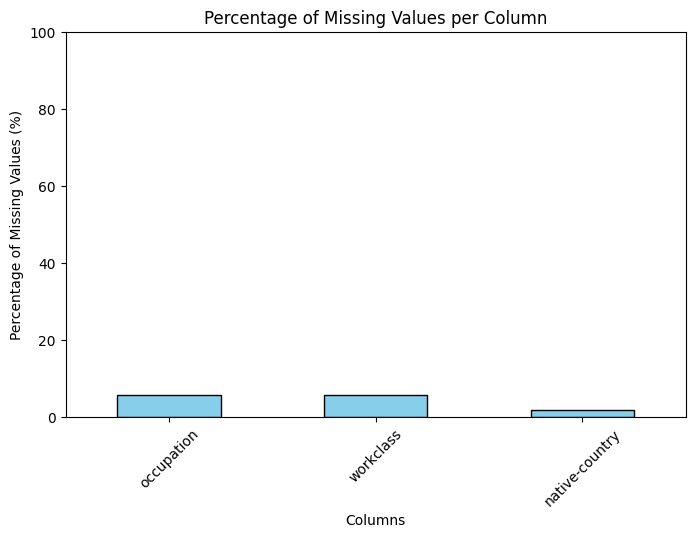

In [ ]:
# calculate the missing percent
missing_percent = train_df.isna().mean() * 100

# Filter only columns that have missing values
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
missing_percent.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Percentage of Missing Values per Column")
plt.ylabel("Percentage of Missing Values (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.ylim(0, 100)  # Force y-axis to show 0–100%
plt.show()

In [ ]:
#encode categorical data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# Separate features and target
X = train_df.drop("income", axis=1)
y = train_df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)  # Binary encoding target

#identify columns type
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric transformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # or fill with "Unknown"
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
#define models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}


In [ ]:
# Use the train_df and test_df you already loaded earlier
X_train = train_df.drop("income", axis=1)
y_train = train_df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)

X_test = test_df.drop("income", axis=1)
y_test = test_df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)


In [ ]:
from sklearn.metrics import classification_report

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

     # Train on adult.data
    clf.fit(X_train, y_train)

    # Evaluate on adult.test
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n Model: {name}")
    print(classification_report(y_test, y_pred))



 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.85      0.88     12434
           1       0.61      0.77      0.68      3846

    accuracy                           0.83     16280
   macro avg       0.77      0.81      0.78     16280
weighted avg       0.85      0.83      0.84     16280


 Model: Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12434
           1       0.72      0.61      0.66      3846

    accuracy                           0.85     16280
   macro avg       0.80      0.77      0.78     16280
weighted avg       0.84      0.85      0.85     16280


 Model: SVM
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     12434
           1       0.76      0.58      0.66      3846

    accuracy                           0.86     16280
   macro avg       0.82      0.76      0.78     16280
weighted 

                 Model  Accuracy
0  Logistic Regression  0.829484
1        Random Forest  0.850676
2                  SVM  0.858170
3                  KNN  0.833722
4    Gradient Boosting  0.869103


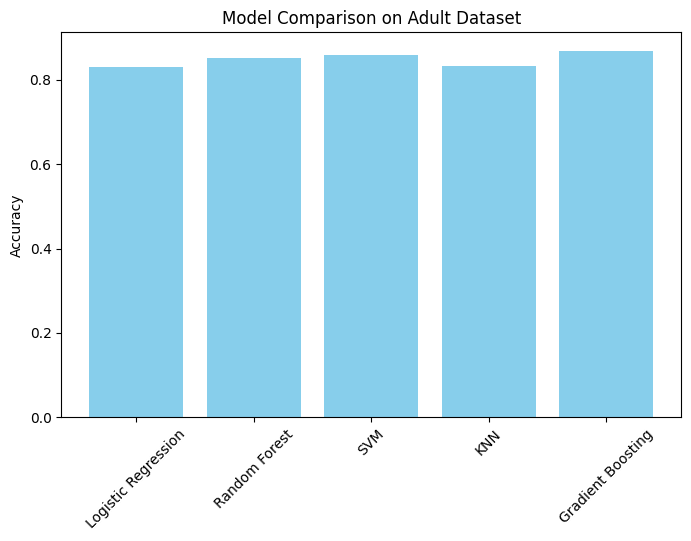

In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df)

# Plot
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color="skyblue")
plt.ylabel("Accuracy")
plt.title("Model Comparison on Adult Dataset")
plt.xticks(rotation=45)
plt.show()
